# MediCare Patient Follow-Up Agent
**Data Scientist Interview Prototype — Single Runnable Notebook**

### Goal
Help the care-coordination team identify patients needing follow-up, explain why, and suggest prioritized next actions.

### Flow
`CSV → Agent tools → LLM tool selection → tool execution → LLM decision → structured result`

The notebook covers the five requested tasks and also exposes the same capabilities through FastAPI.


## Task 1 — Data Loading & Exploratory Analysis
Load the 100-patient snapshot, validate the schema, and inspect diagnoses, missed appointments, labs and visit gaps.


In [11]:
import os, json, re
import pandas as pd
import matplotlib.pyplot as plt
from groq import Groq
from fastapi import FastAPI, HTTPException
from fastapi.testclient import TestClient

DATA_PATH = "patient_data.csv"
MODEL = os.getenv("GROQ_MODEL", "openai/gpt-oss-20b")
df = pd.read_csv(DATA_PATH)
for c in ["last_visit_date", "next_scheduled_visit"]:
    df[c] = pd.to_datetime(df[c], errors="coerce")

print("Shape:", df.shape)
display(df.head())
print("\nMissing values:")
display(df.isna().sum().to_frame("missing").query("missing > 0"))


Shape: (100, 18)


,patient_id,patient_name,age,gender,diagnosis,current_medication,lab_test,lab_value,lab_unit,last_visit_date,next_scheduled_visit,days_since_last_visit,missed_last_appointment,vitals_bp_systolic,vitals_bp_diastolic,vitals_heart_rate,vitals_spo2,notes
0,P0001,Aarav Sharma,68,Male,Type 2 Diabetes,Metformin 500mg,HbA1c,9.9,%,2024-04-24,2024-06-08,251,No,174,70,95,96,Patient reports good medication adherence.
1,P0002,Priya Patel,29,Male,Heart Failure,Furosemide 40mg,BNP,317.6,pg/mL,2024-01-14,2024-02-28,352,No,174,91,72,97,Patient reports no new symptoms.
2,P0003,Rohan Mehta,45,Male,"Type 2 Diabetes, CKD","Insulin Glargine 10U, Losartan 50mg",HbA1c,11.4,%,2024-08-04,2024-10-03,149,No,132,86,64,91,Medication dose adjusted this visit.
3,P0004,Anjali Singh,34,Female,"COPD, Heart Failure","Tiotropium 18mcg, Furosemide 40mg",FEV1%,33.8,%,2024-01-23,2024-04-22,343,No,153,70,93,94,Patient reports no new symptoms.
4,P0005,Vikram Nair,51,Male,"Hypertension, Heart Failure","Amlodipine 5mg, Furosemide 40mg",BP Systolic,124.9,mmHg,2024-04-26,2024-06-25,249,No,134,71,82,94,Patient education provided on diet and lifestyle.



Missing values:


,missing


,metric,value
0,Patients,100
1,Missed last appointment,15
2,Median days since last visit,219


,patients
diagnosis,
Heart Failure,12
Hypothyroidism,9
"Hypertension, Anemia",8
COPD,7
Osteoarthritis,7
"Type 2 Diabetes, Hypertension",7
Depression,7
Type 2 Diabetes,6
"COPD, Heart Failure",6


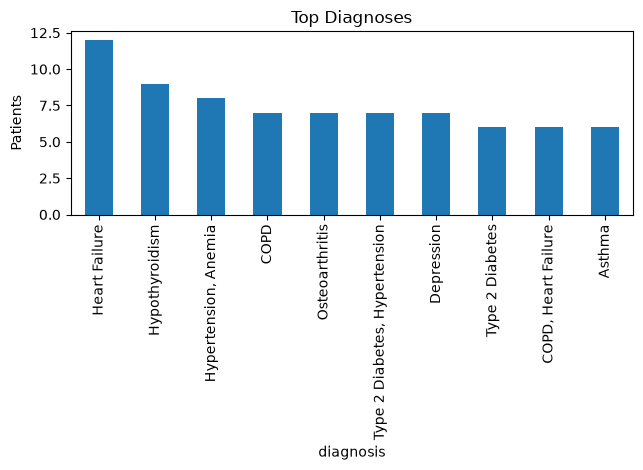

In [12]:
summary = pd.DataFrame({
    "metric": ["Patients", "Missed last appointment", "Median days since last visit"],
    "value": [len(df), (df["missed_last_appointment"].str.lower()=="yes").sum(),
              int(df["days_since_last_visit"].median())]
})
display(summary)
display(df["diagnosis"].value_counts().head(10).to_frame("patients"))
df["diagnosis"].value_counts().head(10).plot(kind="bar", title="Top Diagnoses")
plt.ylabel("Patients"); plt.tight_layout(); plt.show()


## Task 2 — Define Agent Tools
Tools retrieve **facts** from the CSV. They do not decide clinical priority or follow-up actions; that decision is left to the LLM.


In [13]:
def clean_record(row):
    out = {}
    for k, v in row.items():
        if pd.isna(v): out[k] = None
        elif isinstance(v, pd.Timestamp): out[k] = v.strftime("%Y-%m-%d")
        elif hasattr(v, "item"): out[k] = v.item()
        else: out[k] = v
    return out

def get_patient(patient_id):
    x = df[df.patient_id == patient_id]
    if x.empty: return {"error": f"{patient_id} not found"}
    return clean_record(x.iloc[0].to_dict())

def get_missed_patients(limit=100):
    x = df[df.missed_last_appointment.astype(str).str.lower().eq("yes")]
    return [clean_record(r) for r in x.head(limit).to_dict("records")]

def get_population():
    return [clean_record(r) for r in df.to_dict("records")]

TOOLS = {
    "get_patient": get_patient,
    "get_missed_patients": get_missed_patients,
    "get_population": get_population
}
print("Available tools:", list(TOOLS))


Available tools: ['get_patient', 'get_missed_patients', 'get_population']


## Task 3 — Implement the Agentic Loop
The LLM first decides which tool it needs. Python executes that tool. The tool result is then returned to the LLM so it can produce a structured care-coordination decision.

Set `GROQ_API_KEY` in the environment before running. The key is intentionally not stored in the notebook.


In [ ]:
SYSTEM = """
You are a patient follow-up coordination agent, not a diagnosing physician.
Use only facts returned by tools. Do not invent data, diagnoses, or medication changes.
Prioritize follow-up as LOW, MEDIUM, HIGH, or URGENT.
Recommend care-coordination actions such as contact, rescheduling, clinician review, or prompt assessment.
Return valid JSON only.
"""

# Put your real key here while testing.
# Before submission replace it with "YOUR_GROQ_API_KEY"
GROQ_API_KEY = "YOUR_GROQ_API_KEY"

groq_client = Groq(api_key=GROQ_API_KEY)


def llm_json(messages):
    r = groq_client.chat.completions.create(
        model=MODEL,
        messages=messages,
        temperature=0
    )

    content = r.choices[0].message.content.strip()

    content = (
        content
        .replace("```json", "")
        .replace("```", "")
        .strip()
    )

    try:
        return json.loads(content)

    except json.JSONDecodeError:
        print("Invalid JSON returned by LLM:")
        print(content)
        raise


def choose_tool(request):
    prompt = f"""
Request: {request}

You are selecting which Python function should be executed.

Available functions:
1. get_patient(patient_id) - returns one patient record
2. get_missed_patients(limit) - returns patients who missed their appointment
3. get_population() - returns all patients

IMPORTANT:
Do NOT call any function yourself.
Do NOT use tool calling.
Only return a JSON object describing which function Python should execute.

Required format:
{{
    "tool": "get_patient",
    "args": {{
        "patient_id": "P0001"
    }}
}}

User request:
{request}
"""

    return llm_json([
        {"role": "system", "content": SYSTEM},
        {"role": "user", "content": prompt}
    ])


def run_agent(request):
    # Step 1: LLM decides which tool to use
    plan = choose_tool(request)

    name = plan["tool"]
    args = plan.get("args", {})

    if name not in TOOLS:
        raise ValueError(f"Unknown tool: {name}")

    # Step 2: Execute the tool
    observation = TOOLS[name](**args)

    # Step 3: Give tool result back to LLM
    final_prompt = f"""
Request: {request}

Tool used: {name}

Tool result:
{json.dumps(observation, default=str)}

Return JSON with keys:
patient_id,
priority,
risk_summary,
recommended_actions,
rationale.

For a list request return:
{{"patients": [...]}}
using those fields for each patient.
"""

    # Step 4: LLM makes final decision
    result = llm_json([
        {"role": "system", "content": SYSTEM},
        {"role": "user", "content": final_prompt}
    ])

    return {
        "tool_used": name,
        "tool_args": args,
        "result": result
    }

## Task 4 — Single Patient Analysis
The agent decides how to obtain the requested patient's record and then generates a structured follow-up assessment.


In [15]:
single_result = run_agent("Analyze patient P0001 and recommend follow-up priority and actions.")
display(single_result)


{'tool_used': 'get_patient',
 'tool_args': {'patient_id': 'P0001'},
 'result': {'patient_id': 'P0001',
  'priority': 'HIGH',
  'risk_summary': 'Patient has poorly controlled Type 2 Diabetes (HbA1c 9.9%) and elevated systolic blood pressure (174\u202fmmHg). Age 68 increases risk for cardiovascular and diabetic complications.',
  'recommended_actions': ['Contact patient to confirm upcoming appointment on 2024-06-08 and assess willingness for earlier visit if needed.',
   'Schedule an earlier clinician review (within 4–6 weeks) to reassess glycemic control and blood pressure.',
   'Consider medication adjustment: review Metformin dose and evaluate need for antihypertensive therapy.',
   'Refer to diabetes educator for lifestyle counseling and medication adherence support.',
   'Order repeat HbA1c and fasting glucose within 4 weeks to monitor response to any changes.'],
  'rationale': 'The combination of high HbA1c, elevated systolic BP, and advanced age places the patient at increased ris

## Task 5 — Missed Appointment Follow-Up
The agent retrieves patients who missed their last appointment and prioritizes follow-up using the complete records returned by the tool.


In [16]:
missed_result = run_agent(
    "Find patients who missed their last appointment. Prioritize them for follow-up and explain each decision."
)
display(missed_result)


{'tool_used': 'get_missed_patients',
 'tool_args': {'limit': 10},
 'result': {'patients': [{'patient_id': 'P0018',
    'priority': 'HIGH',
    'risk_summary': 'Heart failure with BNP 952.3 pg/mL (very high) and systolic BP 160 mmHg; missed appointment 157 days ago.',
    'recommended_actions': ['Contact patient urgently to reschedule appointment',
     'Arrange prompt cardiology review',
     'Monitor BNP trend'],
    'rationale': 'Elevated BNP indicates worsening heart failure; high BP adds risk; missed visit increases risk of decompensation.'},
   {'patient_id': 'P0031',
    'priority': 'MEDIUM',
    'risk_summary': 'Chronic kidney disease stage 3 (eGFR 52.1 mL/min/1.73m²) with borderline diastolic hypertension; missed appointment 147 days ago.',
    'recommended_actions': ['Schedule nephrology follow-up',
     'Review medication and BP control'],
    'rationale': 'Moderate CKD requires regular monitoring; missed visit may delay adjustments.'},
   {'patient_id': 'P0036',
    'priorit

## Additional Demo — Population Triage
This extends the requested workflow: review the supplied population and surface patients the LLM considers HIGH or URGENT for care-team attention. To keep prompts manageable, records are evaluated in batches rather than relying on one very large prompt.


In [17]:
def population_triage(batch_size=5):
    records = get_population()
    results = []

    for i in range(0, len(records), batch_size):

        batch = records[i:i + batch_size]

        prompt = f"""
Analyze EVERY patient record below.

For each patient assign:
- priority: LOW, MEDIUM, HIGH, or URGENT
- risk_summary
- recommended_actions
- rationale

Return ONLY valid JSON.

Exact structure:

{{
  "patients": [
    {{
      "patient_id": "P0001",
      "priority": "HIGH",
      "risk_summary": "reason",
      "recommended_actions": ["action 1", "action 2"],
      "rationale": "explanation"
    }}
  ]
}}

Do not include markdown.
Do not include text before or after JSON.

Patient records:
{json.dumps(batch, default=str)}
"""

        response = llm_json([
            {"role": "system", "content": SYSTEM},
            {"role": "user", "content": prompt}
        ])

        results.extend(response["patients"])

    order = {
        "URGENT": 0,
        "HIGH": 1,
        "MEDIUM": 2,
        "LOW": 3
    }

    results.sort(
        key=lambda x: order.get(x.get("priority"), 9)
    )

    return results

## FastAPI REST API
FastAPI is defined inside the notebook so the submission remains a single self-contained `.ipynb`.


In [18]:
app = FastAPI(title="MediCare Patient Follow-Up Agent", version="1.0")

@app.get("/health")
def health():
    return {"status":"ok", "patients":len(df)}

@app.post("/patients/{patient_id}/analyze")
def api_analyze(patient_id: str):
    if get_patient(patient_id).get("error"): raise HTTPException(404, "Patient not found")
    return run_agent(f"Analyze patient {patient_id} and recommend follow-up priority and actions.")

@app.post("/followups/missed")
def api_missed():
    return run_agent("Find patients who missed their last appointment and prioritize their follow-up.")

@app.post("/patients/triage")
def api_triage():
    r = population_triage()
    return {"total_reviewed":len(r),
            "attention":[x for x in r if x["priority"] in ("URGENT","HIGH")]}

client = TestClient(app)
print(client.get("/health").json())


{'status': 'ok', 'patients': 100}


In [19]:
api_client = TestClient(app)

In [ ]:
response = api_client.post("/followups/missed")

print(response.status_code)

result = response.json()
display(result)

## Design Notes & Reasoning
- **Facts vs decisions:** pandas/tools retrieve patient facts; the LLM decides priority, rationale and follow-up actions.
- **Agentic behavior:** the LLM selects a tool, receives its observation, then makes the final structured decision.
- **Safety:** this is a care-coordination prototype, not autonomous diagnosis or prescribing. Production use would require clinician-approved rules, validation, audit logging and governance.
- **Population triage:** included as an extension; the five assignment tasks remain the core demonstration.
- **FastAPI:** kept inside the notebook to satisfy the single-notebook requirement while exposing REST endpoints.
- **Run:** place `patient_data.csv` beside this notebook, set `GROQ_API_KEY`, install dependencies, then Run All.
